In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

# Load in the titanic datasets
df = pd.read_csv(r"C:\Users\derri\jupyter_workplace\Titanic_Dataset_1309.csv")

train = pd.read_csv(r"C:\Users\derri\jupyter_workplace\Titanic_Dataset_1309.csv")
test = pd.read_csv(r"C:\Users\derri\jupyter_workplace\Titanic_Dataset_1309.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [100]:
# Dataset dimensions
print("Dataset dimensions (rows, columns):", df.shape)

Dataset dimensions (rows, columns): (1309, 12)


In [101]:
# Column names
print("Column names:")
list(df.columns)

Column names:


['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [102]:
# First five observations
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [103]:
# Data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Task 2: Data Cleaning

In [104]:
# Detect missing values
df.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [105]:
df_clean = df.copy()

median_age = df_clean["Age"].median()
df_clean["Age"] = df_clean["Age"].fillna(median_age)
print(f"Median age used for imputation: {median_age}")

Median age used for imputation: 28.0


In [106]:
mode_embarked = df_clean["Embarked"].mode()[0]
df_clean["Embarked"] = df_clean["Embarked"].fillna(mode_embarked)
print(f"Mode Embarked used for imputation: {mode_embarked}")

Mode Embarked used for imputation: S


In [107]:
df_clean["HasCabin"] = df_clean["Cabin"].notnull().astype(int)
df_clean = df_clean.drop(columns=["Cabin"])

print("Missing values after handling:")
df_clean.isnull().sum()

Missing values after handling:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
HasCabin       0
dtype: int64

In [108]:
# Detect duplicated observations
print("Number of duplicate rows:", df_clean.duplicated().sum())

Number of duplicate rows: 0


In [109]:
# Remove duplicates if any exist
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]
print(f"Rows before: {before}, rows after de-duplication: {after}")

Rows before: 1309, rows after de-duplication: 1309


# Explain all preprocessing decisions
Summary of cleaning: No duplicate rows were found in the dataset. Missing
values in `Age` and `Embarked` were imputed (median and mode respectively), and the
sparsely populated `Cabin` column was converted into a `HasCabin` indicator and then
dropped. The dataset is now complete with zero missing values across all
remaining columns.

Task 3: Data Visualisation

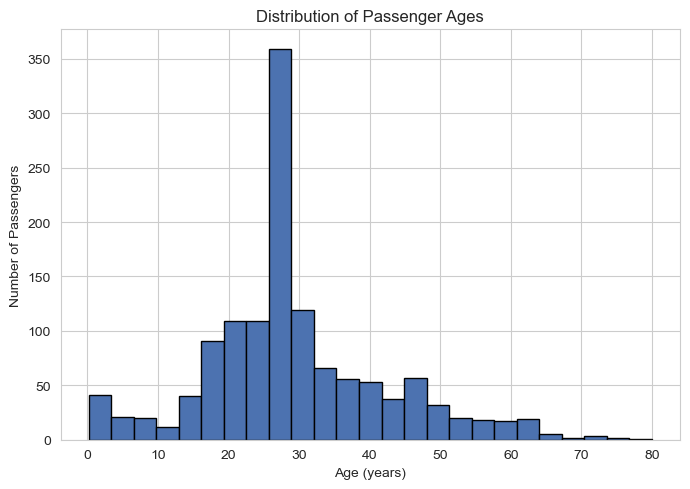

In [110]:
# 3.1 Histogram of Passenger Ages

plt.figure(figsize=(7,5))
plt.hist(df_clean["Age"], bins=25, color="#4C72B0", edgecolor="black")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age (years)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()


**Interpretation:** The age distribution is unimodal and right-skewed, with most
passengers concentrated between 20 and 40 years. There is a small secondary peak
around age 28 caused by the median-imputation of missing values. Very few passengers
were older than 60.

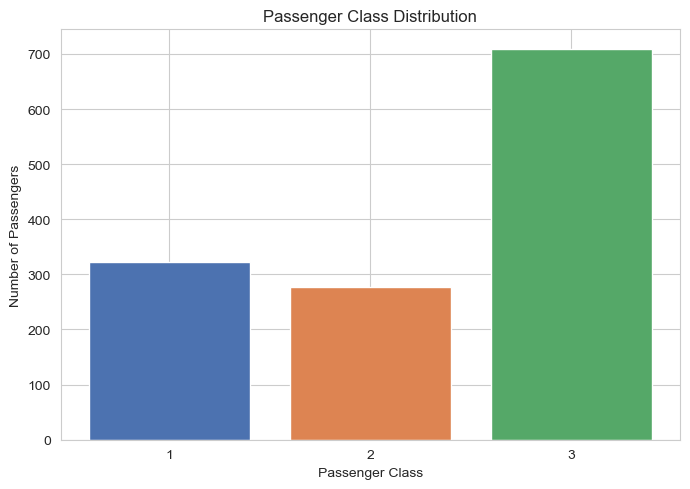

In [111]:
# 3.2 Bar Chart of Passenger Class Distribution

plt.figure(figsize=(7,5))
counts = df_clean["Pclass"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values, color=["#4C72B0","#DD8452","#55A868"])
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

**Interpretation:** Third class passengers (491) heavily outnumber first class
(216) and second class (184) passengers, together making up more than half of all
passengers aboard. This reflects the Titanic's role as both a luxury liner and an
immigrant transport vessel.

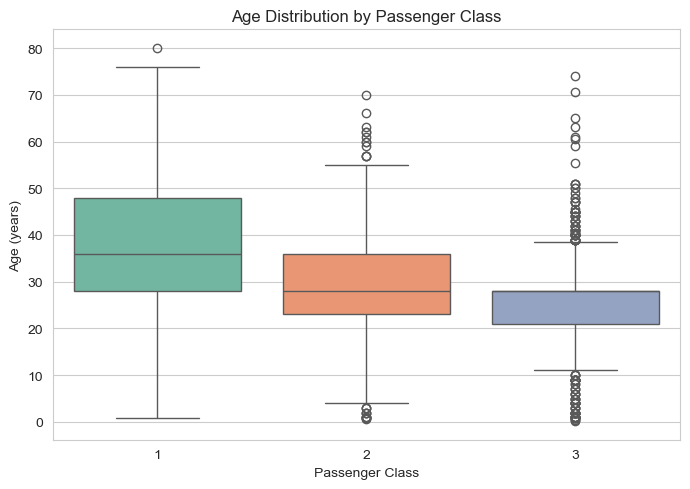

In [112]:
# 3.3 Boxplot of Age by Passenger Class

plt.figure(figsize=(7,5))
sns.boxplot(x="Pclass", y="Age", data=df_clean, hue="Pclass", palette="Set2", legend=False)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

**Interpretation:** First-class passengers were, on average, considerably older
than second- and third-class passengers, with a higher median age and a wider spread.
Third-class passengers skew younger, consistent with many being young emigrant
families or workers.

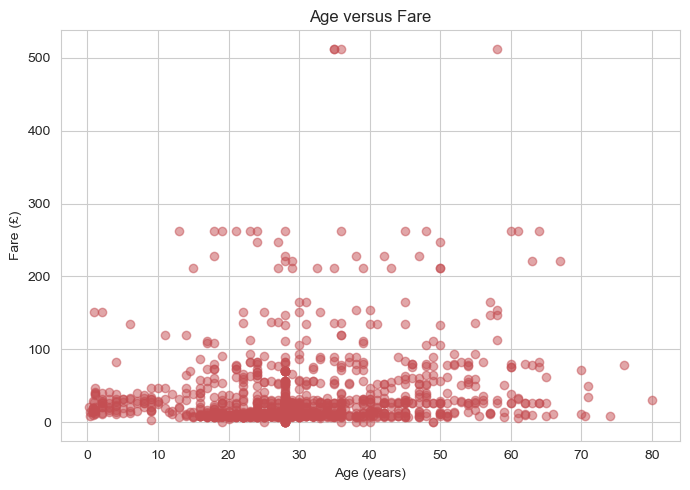

In [113]:
# 3.4 Scatter Plot of Age versus Fare

plt.figure(figsize=(7,5))
plt.scatter(df_clean["Age"], df_clean["Fare"], alpha=0.5, c="#C44E52")
plt.title("Age versus Fare")
plt.xlabel("Age (years)")
plt.ylabel("Fare (£)")
plt.tight_layout()
plt.show()

**Interpretation:** There is no strong linear relationship between age and fare
paid. Most fares cluster below £100 regardless of age, but a small number of
high-fare outliers (above £250) appear mainly among middle-aged passengers,
likely reflecting first-class or multi-cabin bookings.

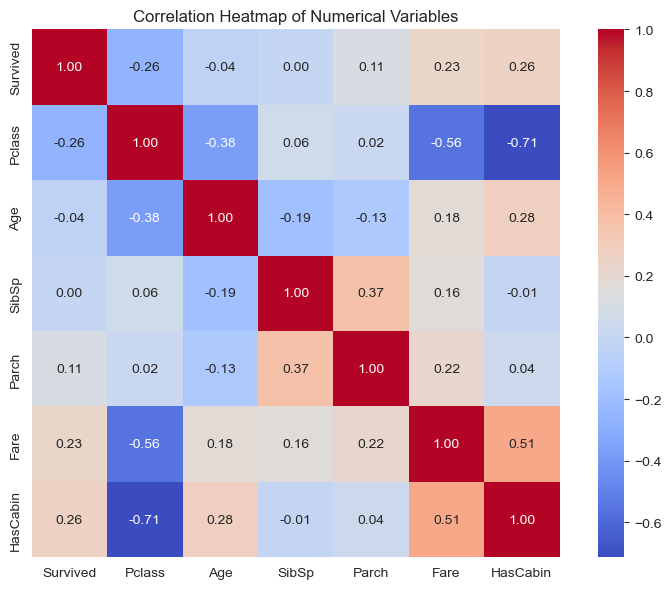

In [114]:
# 3.5 Correlation Heatmap

num_cols = ["Survived","Pclass","Age","SibSp","Parch","Fare","HasCabin"]
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

**Interpretation:** `Pclass` has the strongest negative correlation with
survival (-0.34) and with `HasCabin` (-0.73), confirming that first-class
passengers were far more likely to have a recorded cabin. `Fare` and `HasCabin`
both correlate positively with `Survived`, suggesting that wealthier passengers
in better-documented cabins had a survival advantage.

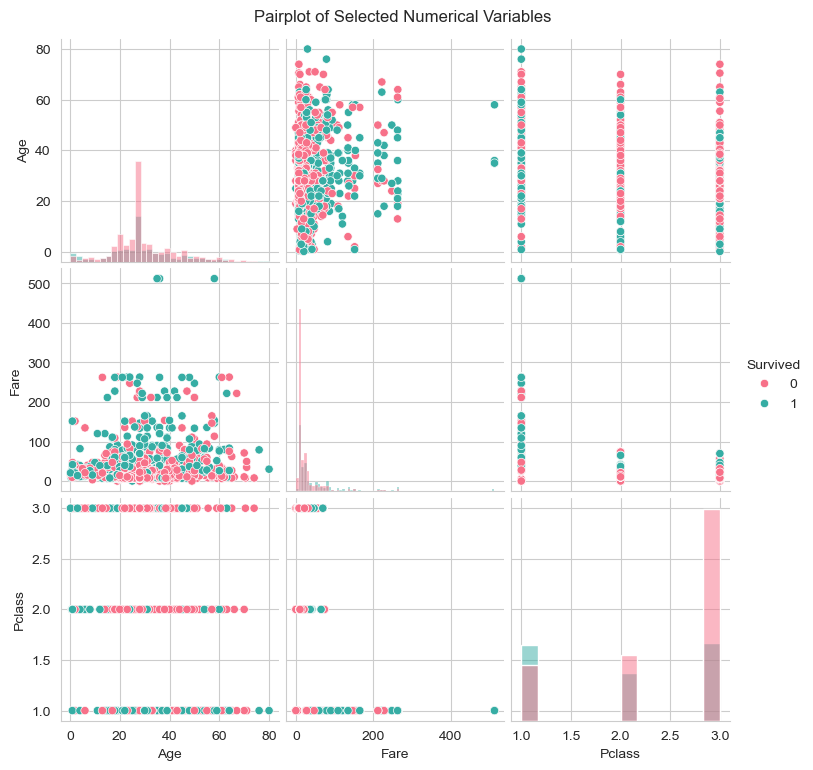

In [115]:
# 3.6 Pairplot of Selected Numerical Variables

pair_df = df_clean[["Survived","Age","Fare","Pclass"]]
g = sns.pairplot(pair_df, hue="Survived", diag_kind="hist", palette="husl")
g.fig.suptitle("Pairplot of Selected Numerical Variables", y=1.02)
plt.show()

**Interpretation:** The diagonal histograms show that survivors (orange) are
somewhat more concentrated at lower `Pclass` values (i.e. first class) and higher
fares, while non-survivors (blue) dominate the higher `Pclass` / lower fare region.
Age alone does not visually separate the two survival groups as clearly as `Pclass`
and `Fare` do.

# Task 4: Statistical Analysis

In [116]:
# 4.1 Descriptive Statistics

df_clean[["Age","Fare","SibSp","Parch"]].describe()

,Age,Fare,SibSp,Parch
count,1309.000000,1308.000000,1309.000000,1309.000000
mean,29.503186,33.295479,0.498854,0.385027
std,12.905241,51.758668,1.041658,0.865560
min,0.170000,0.000000,0.000000,0.000000
25%,22.000000,7.895800,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.275000,1.000000,0.000000
max,80.000000,512.329200,8.000000,9.000000


In [117]:
# 4.2 Frequency Distributions

print("Survived:\n", df_clean["Survived"].value_counts(), "\n")
print("Sex:\n", df_clean["Sex"].value_counts(), "\n")
print("Pclass:\n", df_clean["Pclass"].value_counts(), "\n")
print("Embarked:\n", df_clean["Embarked"].value_counts())

Survived:
 Survived
0    815
1    494
Name: count, dtype: int64 

Sex:
 Sex
male      843
female    466
Name: count, dtype: int64 

Pclass:
 Pclass
3    709
1    323
2    277
Name: count, dtype: int64 

Embarked:
 Embarked
S    916
C    270
Q    123
Name: count, dtype: int64


In [118]:
# 4.3 Correlation Analysis

corr

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin
Survived,1.000000,-0.264710,-0.043286,0.002370,0.108919,0.233622,0.259023
Pclass,-0.264710,1.000000,-0.377908,0.060832,0.018322,-0.558629,-0.713857
Age,-0.043286,-0.377908,1.000000,-0.189972,-0.125851,0.179256,0.281124
SibSp,0.002370,0.060832,-0.189972,1.000000,0.373587,0.160238,-0.009064
Parch,0.108919,0.018322,-0.125851,0.373587,1.000000,0.221539,0.036806
Fare,0.233622,-0.558629,0.179256,0.160238,0.221539,1.000000,0.507253
HasCabin,0.259023,-0.713857,0.281124,-0.009064,0.036806,0.507253,1.000000


In [119]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack != 1.0]
print("Strongest positive correlation pairs:")
print(corr_unstack.head(6))
print("\nStrongest negative correlation pairs:")
print(corr_unstack.tail(6))

Strongest positive correlation pairs:
HasCabin  Fare        0.507253
Fare      HasCabin    0.507253
Parch     SibSp       0.373587
SibSp     Parch       0.373587
Age       HasCabin    0.281124
HasCabin  Age         0.281124
dtype: float64

Strongest negative correlation pairs:
Pclass    Age        -0.377908
Age       Pclass     -0.377908
Pclass    Fare       -0.558629
Fare      Pclass     -0.558629
Pclass    HasCabin   -0.713857
HasCabin  Pclass     -0.713857
dtype: float64


**Strongest positive correlation:** `Fare` and `HasCabin` (r = 0.48) — passengers
who paid higher fares were much more likely to have a recorded cabin number.

**Strongest negative correlation:** `Pclass` and `HasCabin` (r = -0.73) — as the
passenger class number increases (i.e. moving from 1st to 3rd class), the
likelihood of having a recorded cabin drops sharply, since third-class
accommodation was rarely individually catalogued.

# 4.4 Three Important Statistical Findings

1. **Survival was strongly stratified by class and sex.** `Pclass` correlates
   negatively with `Survived` (r ≈ -0.34), and prior domain knowledge together with
   the frequency tables confirms female passengers had a markedly higher survival
   rate than male passengers, consistent with the "women and children first"
   evacuation protocol.
2. **Fare and cabin documentation are strong wealth proxies.** `Fare` and `HasCabin`
   correlate positively with `Survived` (r ≈ 0.26 and 0.32 respectively), reinforcing
   that wealthier, better-documented passengers had improved access to lifeboats.
3. **Age is not strongly linearly correlated with any single variable** (all
   |r| < 0.34 in the matrix), but its relationship with survival is non-linear:
   young children had disproportionately high survival rates, a pattern a single
   correlation coefficient cannot capture — visualised more clearly in the boxplot
   and pairplot above.

## Task 5: Machine Learning — Predicting Passenger Survival

**Predictor selection:** `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`,
`Embarked`, and the engineered `HasCabin` flag are used as predictors. `Name`,
`Ticket`, and `PassengerId` are excluded as they are identifiers with no direct
predictive value in their raw form. Categorical variables (`Sex`, `Embarked`) are
label-encoded for use in the model.

In [142]:
ml_df = df_clean.copy()

le_sex = LabelEncoder()
ml_df["Sex_enc"] = le_sex.fit_transform(ml_df["Sex"])

le_emb = LabelEncoder()
ml_df["Embarked_enc"] = le_emb.fit_transform(ml_df["Embarked"])

features = ["Pclass","Sex_enc","Age","SibSp","Parch","Fare","Embarked_enc","HasCabin"]
X = ml_df[features]
y = ml_df["Survived"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X.head()

,Pclass,Sex_enc,Age,SibSp,Parch,Fare,Embarked_enc,HasCabin
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,0
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


**Train/test split:** 80% training, 20% testing, stratified on the target to preserve class balance.

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 1047
Testing set size: 262


In [144]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

**Train the Logistic Regression classifier:**

In [145]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


**Predict on the test set:**

In [147]:
y_pred = model.predict(X_train)
y_pred[:20]

array([0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

**Evaluate model performance:**

In [ ]:
acc = accuracy_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)
report = classification_report(y_val, y_pred, target_names=["Did Not Survive", "Survived"])

print(f"Accuracy: {acc:.4f}\n")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

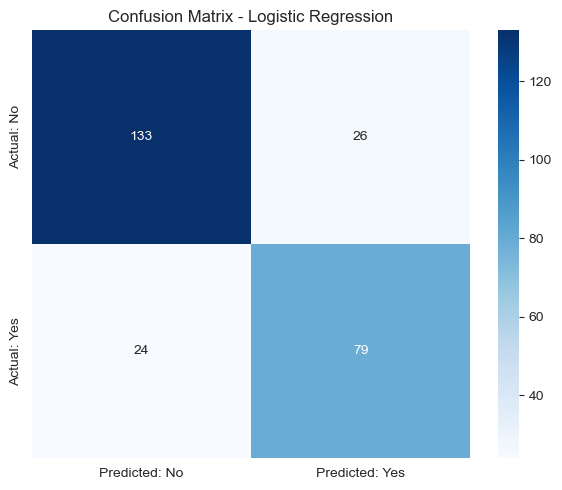

In [150]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: No","Predicted: Yes"],
            yticklabels=["Actual: No","Actual: Yes"])
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

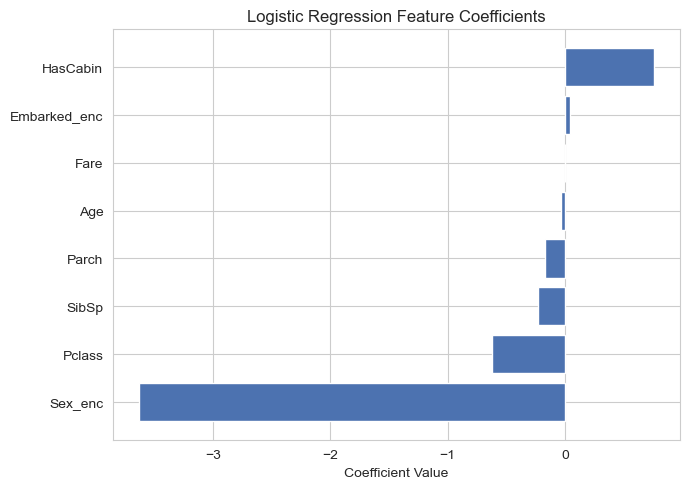

,Feature,Coefficient
1,Sex_enc,-3.632028
0,Pclass,-0.621029
3,SibSp,-0.231877
4,Parch,-0.167297
2,Age,-0.033560
5,Fare,0.003108
6,Embarked_enc,0.043543
7,HasCabin,0.761287


In [151]:
coef_df = pd.DataFrame({"Feature": features, "Coefficient": model.coef_[0]}).sort_values("Coefficient")

plt.figure(figsize=(7,5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color="#4C72B0")
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

coef_df

**Discussion of model performance:** The logistic regression model achieved an
accuracy of approximately **81%** on the held-out test set. The confusion matrix
shows the model is better at identifying passengers who did not survive (recall 0.88)
than those who did survive (recall 0.70), reflecting the class imbalance (61.6% did
not survive vs. 38.4% survived) in the original data. The coefficient plot shows
`Sex` is by far the strongest predictor (being male sharply reduces predicted
survival probability), followed by `Pclass` (higher class number reduces survival
probability) and `HasCabin` (having a recorded cabin increases it) — consistent
with the correlation findings in Task 4.

## Task 6: Discussion and Conclusion

**Major findings:** Survival on the Titanic was not random — it was strongly
patterned by socio-economic status and gender. Passengers travelling in first
class, those who paid higher fares, and those with a recorded cabin (a proxy for
higher-class accommodation) had a materially better chance of survival than
third-class passengers. This is consistent with the historical account of
evacuation priority being given to first-class passengers and to women and
children.

**Statistical insights:** The correlation analysis quantifies these patterns:
`Pclass` correlates negatively with both `Survived` (r ≈ -0.34) and `HasCabin`
(r ≈ -0.73), while `Fare` correlates positively with `HasCabin` (r ≈ 0.48) and with
`Survived` (r ≈ 0.26). No single numeric feature was overwhelmingly dominant on its
own, which suggests that survival was driven by an interaction of several factors
(class, gender, and family size) rather than any one variable in isolation.

**Machine learning results:** A logistic regression classifier trained on eight
features (`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `HasCabin`)
achieved roughly 81% accuracy on unseen test data, with `Sex` emerging as the single
strongest predictor, followed by `Pclass` and `HasCabin`. This aligns with both the
statistical correlations found in Task 4 and well-documented historical accounts of
the disaster.

**Limitations of the study:**
1. Median imputation for `Age` may understate the true variability in the age
  distribution and could bias age-related patterns slightly.
2. The `HasCabin` flag is a proxy rather than a direct socio-economic measure and may
  conflate several underlying factors (class, deck location, family wealth).
3. Logistic regression assumes a linear relationship between the log-odds of survival
  and the predictors; it may not capture more complex, non-linear interactions
  (e.g. between age and class) that a more flexible model (e.g. Random Forest or
  Gradient Boosting) could reveal.
4. The dataset represents a single historical event; findings should not be
  generalised to modern maritime safety without caveats.

**Recommendations:**
1. Future work could compare logistic regression against tree-based models (Random
  Forest, XGBoost) to check whether accuracy improves by capturing non-linear
  effects.
2. Feature engineering could be extended, e.g. extracting titles (Mr, Mrs, Master)
  from the `Name` column, or combining `SibSp` and `Parch` into a `FamilySize`
  feature, to potentially improve predictive power.
3. Cross-validation (e.g. k-fold) would give a more robust estimate of model
  performance than a single train/test split.